In [1]:
# 必要なライブラリをimport
import numpy as np
import seaborn as sns
import pandas as pd
import random

sns.set_theme()

/Users/MisayoMacBookPro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


補足：sns.set_theme() の一文により、そのセルの実行以降のグラフはseabornのスタイルシートを反映させて描くことになります。

In [2]:
# irisのデータを読み込む
data = sns.load_dataset('iris')

In [3]:
# 先頭の5行を表示
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# 列ごとの統計量を確認
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# 品種ごとの統計量を確認
data.groupby('species').describe()

sepal_length                                              \
                  count   mean       std  min    25%  50%  75%  max   
species                                                               
setosa             50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor         50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica          50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal_width         ... petal_length      petal_width         \
                 count   mean  ...          75%  max       count   mean   
species                        ...                                        
setosa            50.0  3.428  ...        1.575  1.9        50.0  0.246   
versicolor        50.0  2.770  ...        4.600  5.1        50.0  1.326   
virginica         50.0  2.974  ...        5.875  6.9        50.0  2.026   

                                               
                 std  min  25%  50%  75%  max  
species                                        
setosa      0.105386  0.1  0.2  0.2  0.3  0.6  
versicolor  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica   0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

describe() はすべてのデータを表示しようとするため、データが多いと表示が途中で省略されてしまいます。その場合は、統計量ごとの表示をしてください。以下は一例です。

In [7]:
# 品種ごとの平均を確認
data.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [8]:
# 品種ごとの標準偏差を確認
data.groupby('species').std()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


In [9]:
# 品種ごとの最小値を確認
data.groupby('species').min()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,4.3,2.3,1.0,0.1
versicolor,4.9,2.0,3.0,1.0
virginica,4.9,2.2,4.5,1.4


In [10]:
# 品種ごとの最大値を確認
data.groupby('species').max()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.8,4.4,1.9,0.6
versicolor,7.0,3.4,5.1,1.8
virginica,7.9,3.8,6.9,2.5


これらを品種ごとに分けておきます。

In [14]:
# データを品種ごとに分ける
setosa = data.query("species == 'setosa'").reset_index(drop=True)
versicolor = data.query("species == 'versicolor'").reset_index(drop=True)
virginica = data.query("species == 'virginica'").reset_index(drop=True)


seabornを使って、setosaのがく片の長さについてヒストグラムを作成してみます。ライブラリをimportするところで記述した sns.set_theme() の一文により、そのセルの実行以降のグラフはseabornのスタイルシートを反映させて描くことになります。

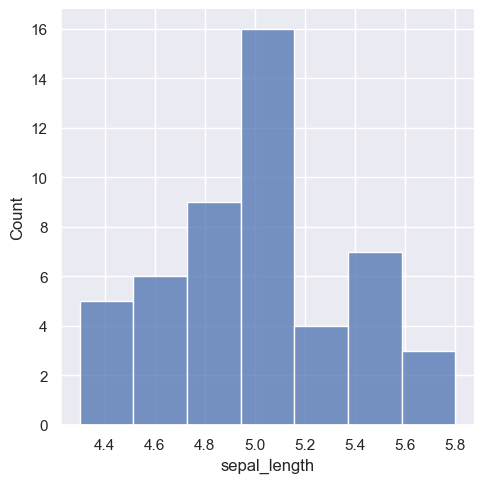

In [15]:
# ヒストグラムを描画
sns.displot(setosa['sepal_length'], kde=False)

次に、このヒストグラムに確率分布を上書きします。kde=Trueとすることで確率分布を表示できます。

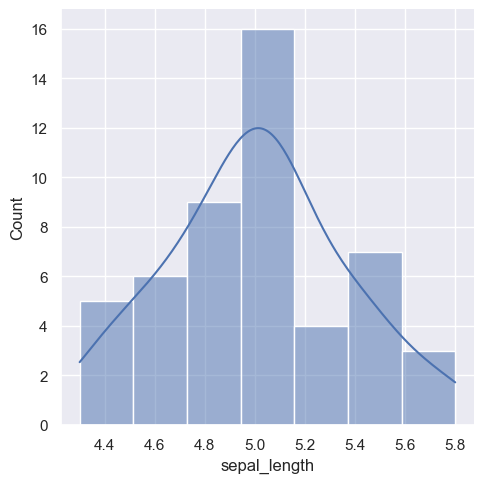

In [16]:
# ヒストグラムと確率分布を描画
sns.displot(setosa['sepal_length'], kde=True)

ヒストグラムは1種類のデータだけでなく、複数のデータを同じグラフに載せることもできます。1つは、下記のコードのように新しいDataFrameを作り、displot() に渡す方法です。

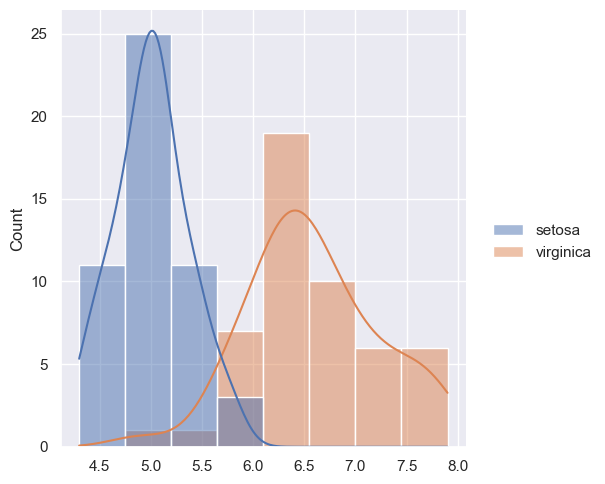

In [14]:
# setosaとvirginicaのヒストグラムと確率分布を描画
data2 = pd.DataFrame(columns=['setosa', 'virginica'])
data2['setosa'] = setosa['sepal_length']
data2['virginica'] = virginica['sepal_length']
sns.displot(data2, kde=True)

もしくは、分割前のデータを displot() に渡し、グラフにしたいデータ（今回は sepal_length）をx 引数に、分割したい列名（今回は species）を hue 引数に指定することで全品種のヒストグラムを描けます。

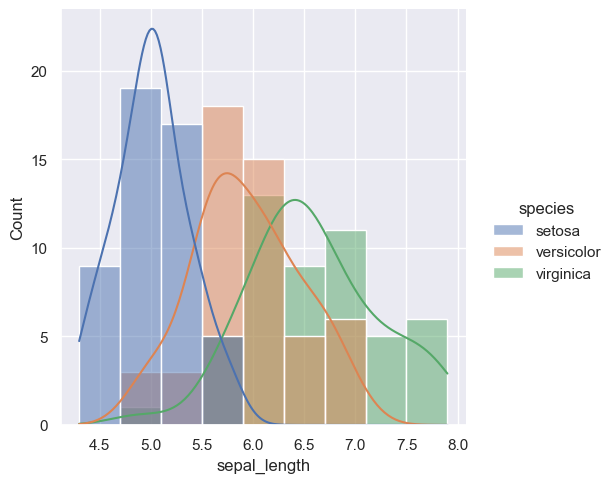

In [15]:
# 全品種のsepal_lengthのヒストグラムと確率分布を描画
sns.displot(data, kde=True, x='sepal_length', hue='species')

<Axes: xlabel='species', ylabel='sepal_length'>

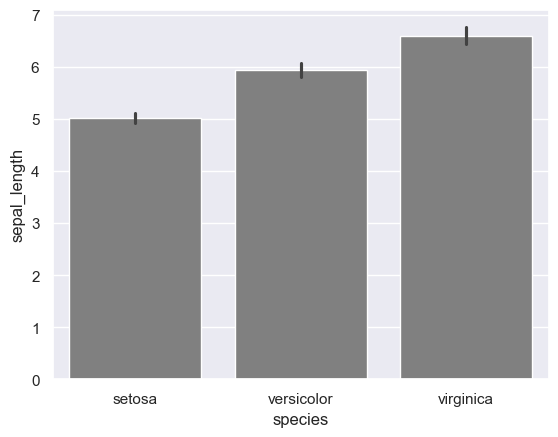

In [ ]:
# 棒グラフを描画(平均値の棒グラフ)
sns.barplot(x='species', y='sepal_length', data=data, color = 'gray')

<Axes: xlabel='species', ylabel='sepal_length'>

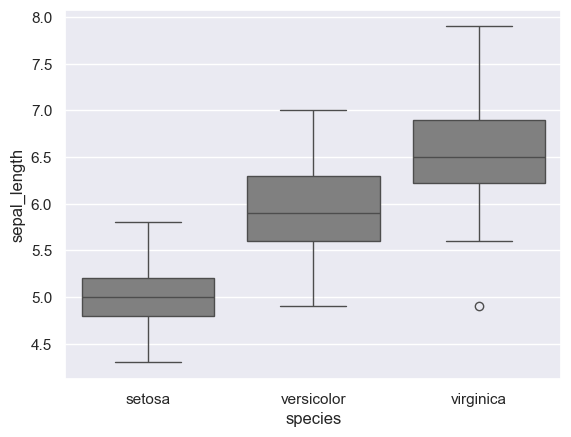

In [20]:
# 箱ひげ図を描画
sns.boxplot(x='species', y='sepal_length', data=data, color = 'gray')

<Axes: xlabel='species', ylabel='sepal_length'>

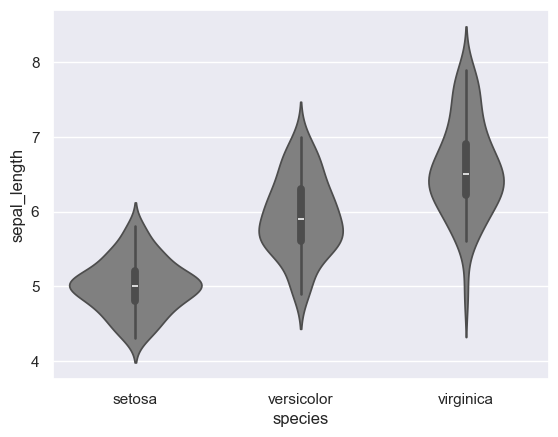

In [21]:
# バイオリンプロットを描画
sns.violinplot(x='species', y='sepal_length', data=data, color = 'gray')

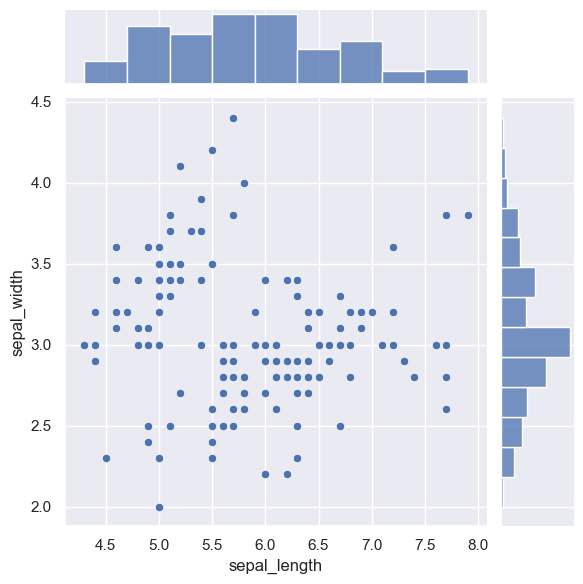

In [22]:
# 散布図を描画
sns.jointplot(x='sepal_length', y='sepal_width', data=data)

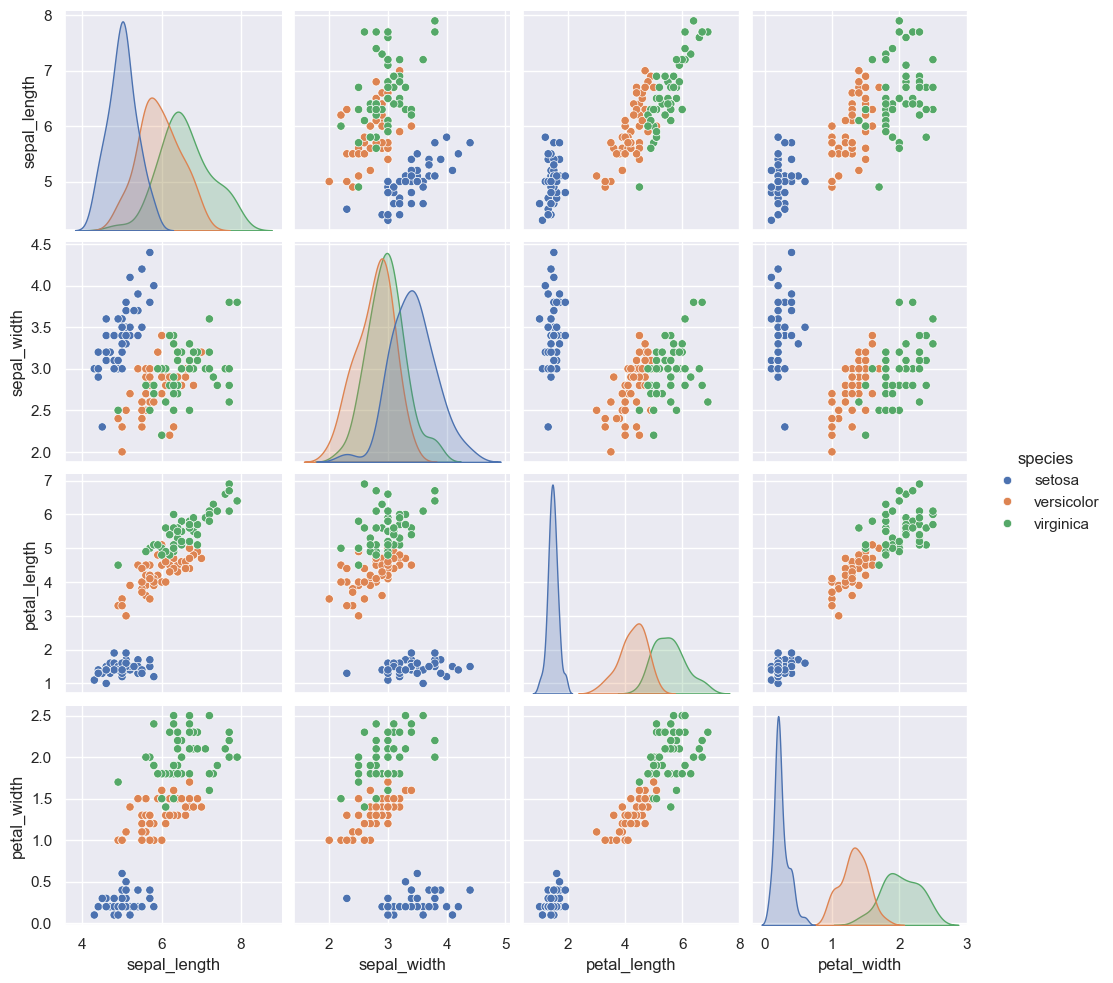

In [23]:
# ペアプロットを描画
sns.pairplot(data, hue='species')